Training MSE: 0.0071


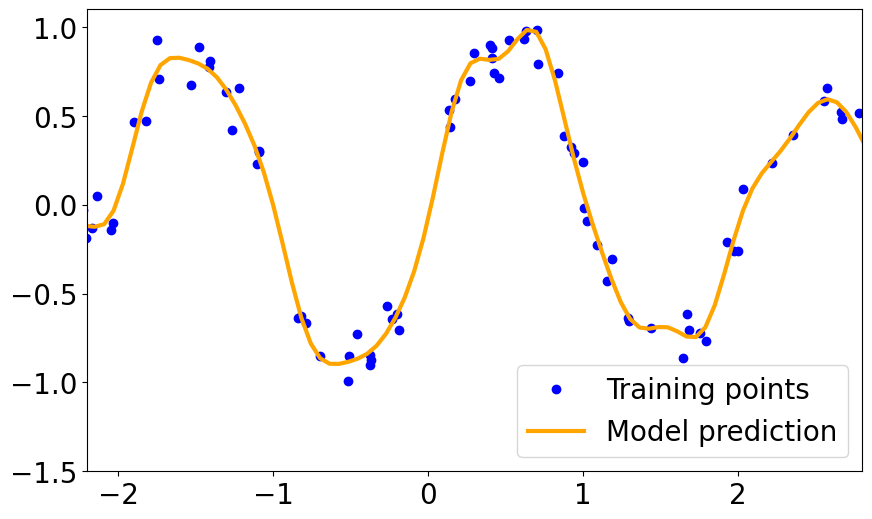

Test MSE: 0.0134


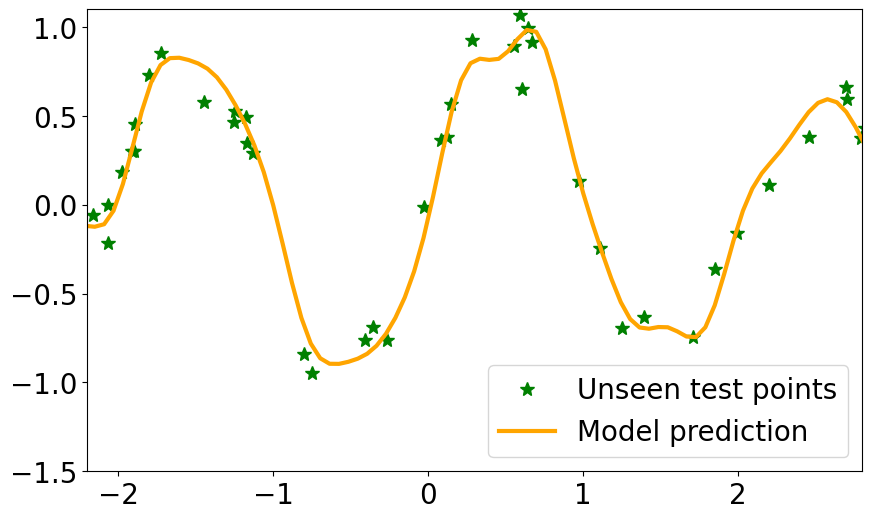

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from pathlib import Path

# Define the true function
def true_function(x):
    return np.sin(3 * x) * np.exp(-0.1 * x**2) + 0.1 * np.sin(10 * x)

# Generate training data
np.random.seed(0)
x_train = np.sort(np.random.uniform(-3, 3, 100))[:, np.newaxis]
y_train = true_function(x_train) + np.random.normal(scale=0.1, size=x_train.shape)

# Function to create trigonometric polynomial features
def trig_poly_features(x):
    features = [np.ones((x.shape[0], 1))]
    for i in range(1, 16):
        features.append(np.sin(i * x))
        features.append(np.cos(i * x))
    return np.hstack(features)

# Create transformer and pipeline
trig_transformer = FunctionTransformer(trig_poly_features, validate=True)
model = Pipeline([
    ('trig_features', trig_transformer),
    ('linear_regression', LinearRegression())
])

# Fit the model
model.fit(x_train, y_train)

# Generate predictions on the training domain
x_model = np.linspace(-3, 3, 100)[:, np.newaxis]
y_model = model.predict(x_model)

# Compute MSE for training data
y_train_pred = model.predict(x_train)
train_mse = mean_squared_error(y_train, y_train_pred)
print(f"Training MSE: {train_mse:.4f}")

# Define the ranges for axes
x_range = (-2.2, 2.8)
y_range = (-1.5, 1.1)

# Plot training data and model predictions
plt.figure(figsize=(10, 6))
plt.plot(x_train, y_train, 'bo', label='Training points')
plt.plot(x_model, y_model, 'orange', linewidth=3, label='Model prediction')
plt.xlim(x_range)
plt.ylim(y_range)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()

# Generate unseen test data
np.random.seed(42)
x_test = np.sort(np.random.uniform(-3, 3, 50))[:, np.newaxis]
y_test = true_function(x_test) + np.random.normal(scale=0.1, size=x_test.shape)

# Generate predictions on unseen data
y_test_pred = model.predict(x_test)

# Compute MSE for unseen data
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {test_mse:.4f}")

# Plot unseen data predictions
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_test, 'g*', markersize=10, label='Unseen test points')  # Green stars for unseen data
plt.plot(x_model, y_model, 'orange', linewidth=3, label='Model prediction')
plt.xlim(x_range)
plt.ylim(y_range)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.show()